In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import seaborn as sns
import numpy as np
import plotly.express as px
import sqlite3
import requests

%matplotlib inline

In [2]:
#import data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
df = pd.read_csv(url)
df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


In [5]:
#check data dimensions
df.shape

(11552, 85)

In [8]:
#identify data types of each column
df.dtypes

Respondent       int64
MainBranch      object
Hobbyist        object
OpenSourcer     object
OpenSource      object
                 ...  
Sexuality       object
Ethnicity       object
Dependents      object
SurveyLength    object
SurveyEase      object
Length: 85, dtype: object

In [11]:
# show how many countries participated in the survey
len(df['Country'].unique())

135

# Data Wrangling


In [14]:
#show duplicate rows
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
1168,2339,I am a developer by profession,Yes,Once a month or more often,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,24.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1169,2342,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,Some college/university study without earning ...,"Information systems, information technology, o...",...,Somewhat more welcome now than last year,Tech meetups or events in your area;Courses on...,24.0,Man,No,Straight / Heterosexual,White or of European descent,No,Too long,Easy
1170,2343,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of LOWER quality than prop...",Employed full-time,Canada,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Indu...,27.0,Man,No,Straight / Heterosexual,Black or of African descent;White or of Europe...,No,Appropriate in length,Neither easy nor difficult
1171,2344,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,24.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1172,2347,I am a developer by profession,Yes,Never,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,NaN,Woman,No,Straight / Heterosexual,Biracial,No,Too long,Easy


In [16]:
#drop duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [18]:
#find out how many missing values are in 'WorkLoc' column
df['WorkLoc'].isnull().sum()

32

In [20]:
#find out the common entries in 'WorkLoc'
df['WorkLoc'].value_counts().to_frame()

,count
WorkLoc,
Office,6806
Home,3589
"Other place, such as a coworking space or cafe",971


In [22]:
#impute missing values with the majority value in 'WorkLoc' column
most_freq = df['WorkLoc'].value_counts().idxmax()
df_workloc_fill = df[['WorkLoc']].fillna(most_freq)

There are two columns in the dataset that talk about compensation. One is "CompFreq". This column shows how often a developer is paid (Yearly, Monthly, Weekly). The other is "CompTotal". This column talks about how much the developer is paid per Year, Month, or Week depending upon the developer "CompFreq".

This makes it difficult to compare the total compensation of the developers. To make comparison much easier, the column 'NormalizedAnnualCompensation' which contains the 'Annual Compensation' irrespective of the 'CompFreq'.

The logic for the entries in the new column is described as follows:

    If the CompFreq is Yearly then use the exising value in CompTotal
    If the CompFreq is Monthly then multiply the value in CompTotal with 12 (months in an year)
    If the CompFreq is Weekly then multiply the value in CompTotal with 52 (weeks in an year)



In [25]:
#check unique values of 'Compfreq'
df['CompFreq'].unique()

array(['Yearly', 'Monthly', 'Weekly', nan], dtype=object)

In [27]:
#replace unique values with salary frequency (1,12,52)
df['CompFreq'].replace('Yearly', 1, inplace=True)
df['CompFreq'].replace('Monthly', 12, inplace=True)
df['CompFreq'].replace('Weekly', 52, inplace=True)
df['CompFreq'].unique()

array([ 1., 12., 52., nan])

In [29]:
#computed normalized compensation using apply()
df['NormalizedAnnualCompensation'] = df.apply(lambda row: row['CompTotal']*1 if row['CompFreq'] == 1 else
                                                          row['CompTotal']*12 if row['CompFreq'] == 12 else
                                                          row['CompTotal']*52 if row['CompFreq'] == 52 else
                                                          np.nan, axis=1)
df[['CompTotal', 'CompFreq', 'NormalizedAnnualCompensation']].head(20)

,CompTotal,CompFreq,NormalizedAnnualCompensation
0,61000.0,1.0,61000.0
1,138000.0,1.0,138000.0
2,90000.0,1.0,90000.0
3,29000.0,12.0,348000.0
4,90000.0,1.0,90000.0
5,9500.0,12.0,114000.0
6,3000.0,12.0,36000.0
7,103000.0,1.0,103000.0
8,69000.0,1.0,69000.0
9,8000.0,12.0,96000.0


# Exploratory Data Analysis

The values in the column 'NormalizedAnnualCompensation' are converted to USD as shown in the column 'ConvertedComp'.

C:\Users\91766\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 500x300 with 0 Axes>

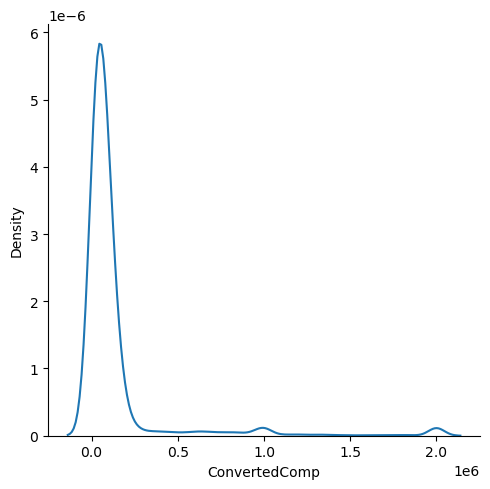

In [33]:
#plot distribution curve of 'ConvertedComp'
plt.figure(figsize=(5,3))
sns.displot(data=df,x='ConvertedComp',kind='kde')
plt.show()

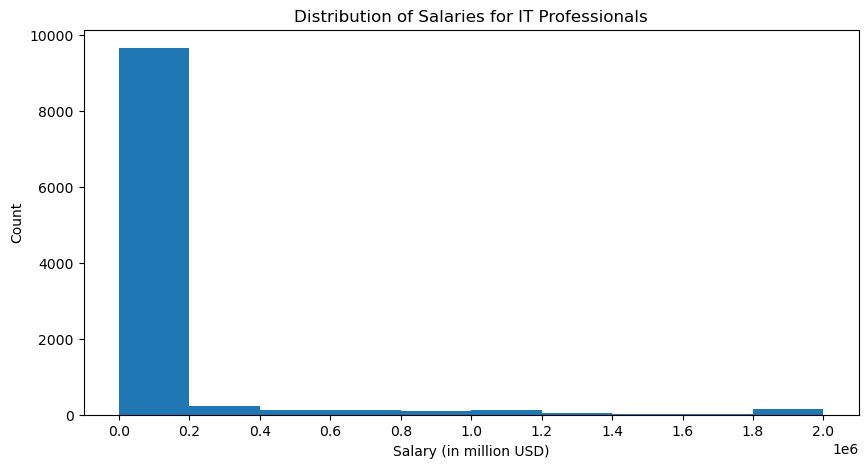

In [35]:
#plot histogram of 'ConvertedComp'
df_new = df.dropna(subset='ConvertedComp')

count, bin_edges = np.histogram(df_new['ConvertedComp'])

plt.figure(figsize=(10,5))
df_new['ConvertedComp'].plot(kind='hist', xticks=bin_edges)
plt.xlabel('Salary (in million USD)')
plt.ylabel('Count')
plt.title('Distribution of Salaries for IT Professionals')
plt.show()

In [37]:
#What is the median salary of IT professionals
df['ConvertedComp'].median()

57745.0

In [39]:
#How many responders identified themselves only as a Man?
df['Gender'].value_counts().to_frame()

,count
Gender,
Man,10480
Woman,731
"Non-binary, genderqueer, or gender non-conforming",63
"Man;Non-binary, genderqueer, or gender non-conforming",26
"Woman;Non-binary, genderqueer, or gender non-conforming",14
Woman;Man,9
"Woman;Man;Non-binary, genderqueer, or gender non-conforming",2


In [41]:
# Find out the median compensation of women in IT.
df_women = df[df['Gender'] == 'Woman']
df_women['ConvertedComp'].median()

57708.0

In [43]:
# What is the five number summary of the column 'Age'?
df['Age'].describe()

count    11111.000000
mean        30.778895
std          7.393686
min         16.000000
25%         25.000000
50%         29.000000
75%         35.000000
max         99.000000
Name: Age, dtype: float64

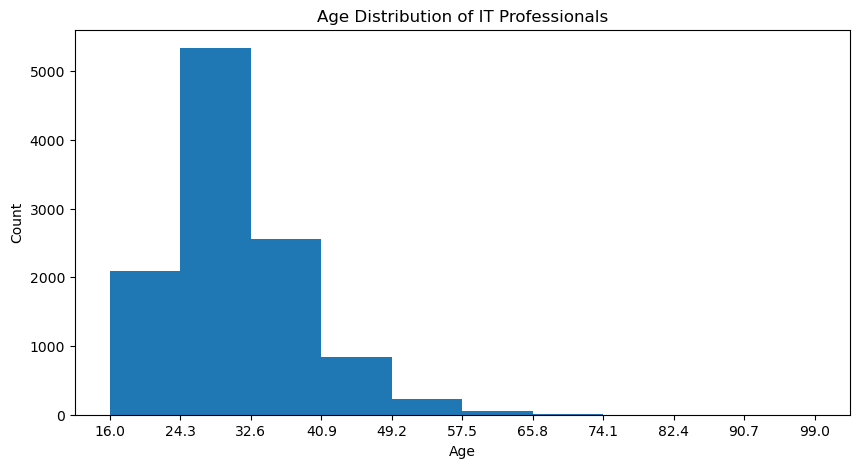

In [45]:
# Show age distribution among IT professionals.
df_new = df.dropna(subset='Age')

count, bin_edges = np.histogram(df_new['Age'])

plt.figure(figsize=(10,5))
df_new['Age'].plot(kind='hist', xticks=bin_edges)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution of IT Professionals')
plt.show()

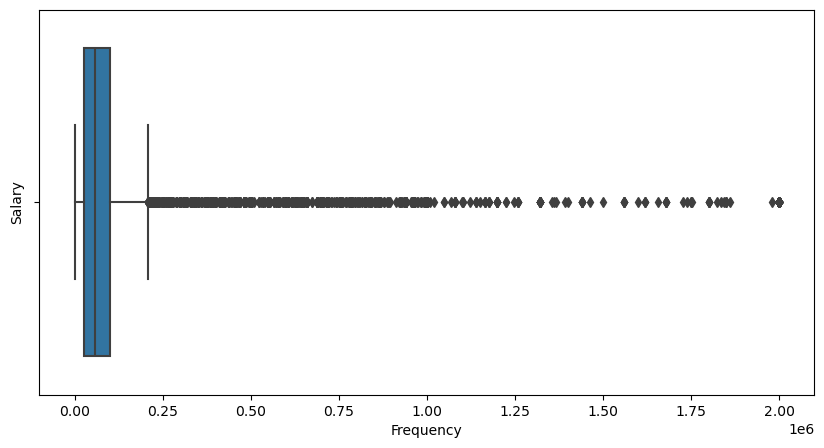

In [47]:
# Find out if outliers exist in the column ConvertedComp.
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='ConvertedComp')
plt.xlabel('Frequency')
plt.ylabel('Salary')
plt.show()

In [49]:
# How many outliers are there in the 'ConvertedComp' column?

# Define inter-quartile range (IQR)
q1 = df['ConvertedComp'].quantile(0.25)
q3 = df['ConvertedComp'].quantile(0.75)
iqr = q3-q1

# Define upper and lower boundaries of IQR
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

# Check column elements if outside upper and lower boundaries (i.e., outliers)
outliers = (df['ConvertedComp']< lower_bounds) | (df['ConvertedComp'] > upper_bounds)
outliers.value_counts()

ConvertedComp
False    10519
True       879
Name: count, dtype: int64

In [51]:
# Create new dataframe without the outliers from the 'ConvertedComp' column
outliers_df = df[(df['ConvertedComp']< lower_bounds) | (df['ConvertedComp'] > upper_bounds)]

# Include row in a new dataframe if not outlier.
df_no_outliers = df[~df.index.isin(outliers_df.index)]
df_no_outliers

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase,NormalizedAnnualCompensation
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy,61000.0
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult,138000.0
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy,90000.0
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy,90000.0
5,19,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,Brazil,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Indu...,31.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina,Yes,Too long,Easy,114000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11547,25136,I am a developer by profession,Yes,Never,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Cour...,36.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Difficult,130000.0
11548,25137,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,Poland,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Tech...,25.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult,74400.0
11549,25138,I am a developer by profession,Yes,Less than once per year,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Tech articles written by other developers;Indu...,34.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Too long,Easy,105000.0
11550,25141,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of LOWER quality than prop...",Employed full-time,Switzerland,No,"Secondary school (e.g. American high school, G...",NaN,...,NaN,25.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy,80000.0


In [53]:
# check correlation of all numeric values in new dataframe
df_no_outliers.corr(numeric_only=True)

,Respondent,CompTotal,CompFreq,ConvertedComp,WorkWeekHrs,CodeRevHrs,Age,NormalizedAnnualCompensation
Respondent,1.000000,-0.019364,0.010709,0.010878,-0.015275,0.002980,0.003950,0.001328
CompTotal,-0.019364,1.000000,0.024001,-0.063561,0.004975,0.017536,0.006371,0.703651
CompFreq,0.010709,0.024001,1.000000,-0.397297,-0.016930,0.059881,-0.153276,0.085273
ConvertedComp,0.010878,-0.063561,-0.397297,1.000000,0.034351,-0.088934,0.401821,-0.086286
WorkWeekHrs,-0.015275,0.004975,-0.016930,0.034351,1.000000,0.031963,0.037452,0.009939
CodeRevHrs,0.002980,0.017536,0.059881,-0.088934,0.031963,1.000000,-0.017961,0.039086
Age,0.003950,0.006371,-0.153276,0.401821,0.037452,-0.017961,1.000000,-0.016294
NormalizedAnnualCompensation,0.001328,0.703651,0.085273,-0.086286,0.009939,0.039086,-0.016294,1.000000


# Data Visualization

<Figure size 1000x500 with 0 Axes>

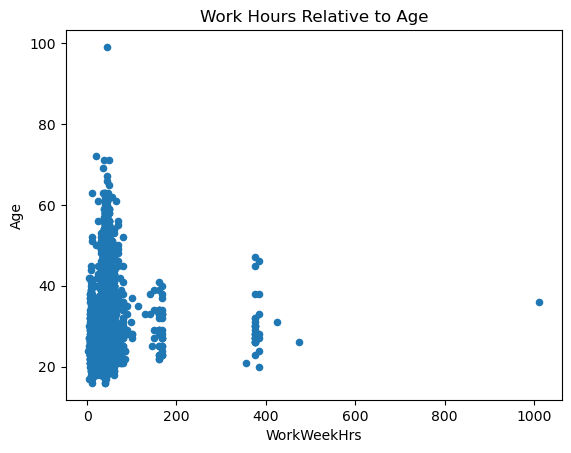

In [56]:
# Show relationship of 'Age' and 'WorkWeekHrs'
plt.figure(figsize=(10,5))
df_no_outliers.plot(kind='scatter', x='WorkWeekHrs', y='Age')
plt.title('Work Hours Relative to Age')
plt.xlabel('WorkWeekHrs')
plt.ylabel('Age')
plt.show()

Majority of software developers work between 0-100 per week. Since a week only has 168 hours, it is not possible to have work week hours beyond this value.

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

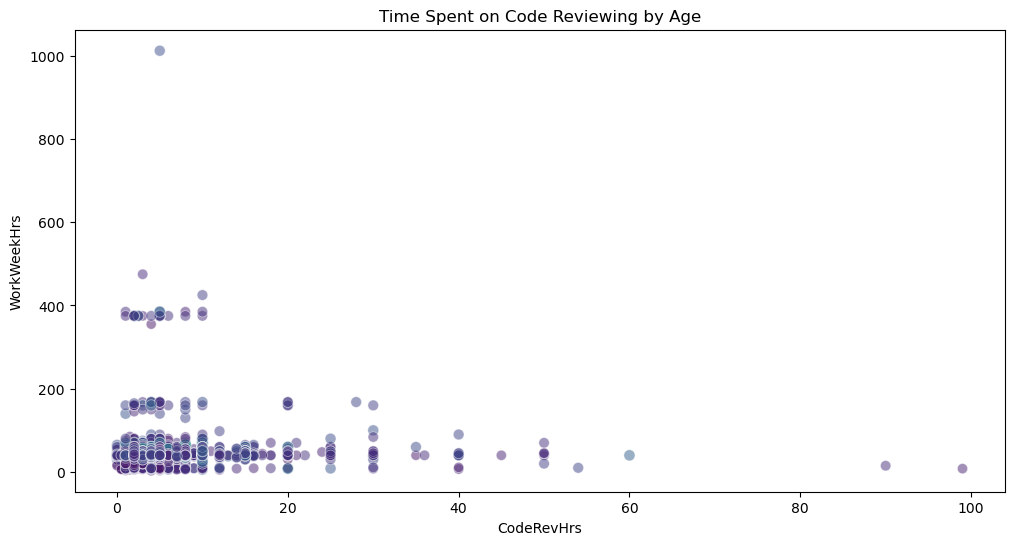

In [59]:
# Create a bubble plot of 'WorkWeekHrs' and 'CodeRevHrs', use 'Age' column as bubble size

# Convert hue_values to numeric
hue_values_numeric = np.array(df_no_outliers['Age'], dtype=float)

plt.figure(figsize=(12,6))
sns.scatterplot(data=df_no_outliers, x='CodeRevHrs', y='WorkWeekHrs', size='Age', hue=hue_values_numeric, 
                palette="viridis", sizes=(50, 100), alpha=0.5, legend=False)
plt.title('Time Spent on Code Reviewing by Age')

# Create a Color Scale legend for Age.
sm = ScalarMappable(cmap='viridis')
sm.set_array(hue_values_numeric)
cbar = plt.colorbar(sm, label='Age')

plt.show()

Majority of the respondents say that they spend almost 50 hours a week reviewing their codes.

In [62]:
# Create a pie chart of the top 5 databases that respondents wish to learn next year
df_no_outliers['DatabaseDesireNextYear'].value_counts()

DatabaseDesireNextYear
PostgreSQL                                                                             494
Microsoft SQL Server                                                                   486
MongoDB                                                                                277
MySQL                                                                                  234
PostgreSQL;Redis                                                                       188
                                                                                      ... 
Cassandra;MariaDB;MongoDB;Microsoft SQL Server;MySQL;Oracle;PostgreSQL;Redis;SQLite      1
DynamoDB;Firebase;MariaDB;MongoDB;Microsoft SQL Server;MySQL;Redis                       1
DynamoDB;Firebase;MongoDB;Microsoft SQL Server;MySQL;Oracle;SQLite                       1
MariaDB;Redis;SQLite;Other(s):                                                           1
Couchbase;Firebase;MariaDB;MongoDB;Oracle                          

Several respondents have multiple entries and are delimited by semicolon. To account all entries in the tally, it is necessary to split each data that have multiple entries. A function is created that will break the data points that are delimited by semicolon and add them to new rows.


In [65]:
# data splitter function
def split_and_create_row(data_frame, column):
    values = data_frame[column].split(';')
    return pd.Series(values)

In [67]:
db_ny_df = df_no_outliers['DatabaseDesireNextYear'].astype(str).to_frame()
db_ny_df.head()

,DatabaseDesireNextYear
0,MySQL;SQLite
1,PostgreSQL;Redis;SQLite
2,Firebase;MySQL;Redis
4,Elasticsearch;Firebase;MongoDB;PostgreSQL
5,DynamoDB


In [69]:
# Apply the function to each row in df['DatabaseDesireNextYear']
#db_next_yr_df = db_ny_df.apply(split_and_create_row, axis=1).stack().reset_index(level=1, drop=True).to_frame('DatabaseDesireNextYear')
db_next_yr_df = db_ny_df.apply(split_and_create_row, axis=1, args=('DatabaseDesireNextYear',)).stack().reset_index(level=1, drop=True).to_frame('DatabaseDesireNextYear')

# Reset index
db_next_yr_df.reset_index(drop=True, inplace=True)
db_next_yr_df

,DatabaseDesireNextYear
0,MySQL
1,SQLite
2,PostgreSQL
3,Redis
4,SQLite
...,...
28498,Elasticsearch
28499,MongoDB
28500,Microsoft SQL Server
28501,Redis


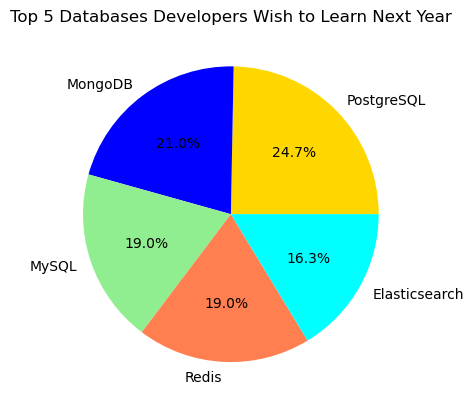

In [71]:
# Count each entry
new_df = db_next_yr_df.value_counts().to_frame()
new_df.reset_index(inplace=True)
top5_df = new_df.head(5)

# Create pie chart
fig, ax = plt.subplots()

ax.pie(top5_df['count'], labels=top5_df['DatabaseDesireNextYear'],
      colors = ['gold','blue','lightgreen','coral','cyan'],
      autopct = '%1.1f%%') #set decimal point to 1
plt.title('Top 5 Databases Developers Wish to Learn Next Year')
ax.set_aspect('equal') #ensure pie is drawn as a circleMultiple plots and sub-plotting

In [73]:
# Create a pie chart of the top 5 languages that respondents wish to learn next year
df_no_outliers['LanguageDesireNextYear'].value_counts()

LanguageDesireNextYear
C#;HTML/CSS;JavaScript;SQL;TypeScript                                              109
Python                                                                             105
C#;HTML/CSS;JavaScript;SQL                                                          87
HTML/CSS;JavaScript;TypeScript                                                      82
HTML/CSS;JavaScript                                                                 68
                                                                                  ... 
C;C#;Java;JavaScript;Python;SQL                                                      1
C;C++;Dart;Go;SQL                                                                    1
Erlang;Go;HTML/CSS;Java;JavaScript;Kotlin;Objective-C;PHP;Python;Ruby;Scala;SQL      1
Bash/Shell/PowerShell;Go;Python;Ruby                                                 1
C++;C#;F#                                                                            1
Name: count, Length:

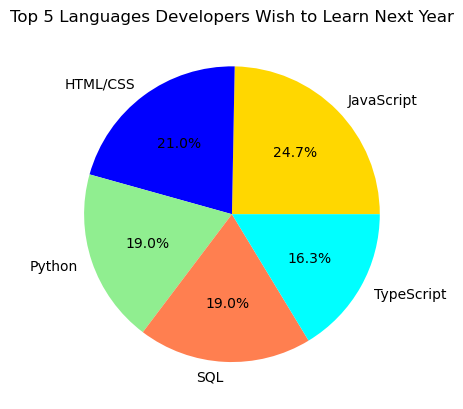

In [75]:
# Separate the df_no_outliers['LanguageDesireNextYear'] into new df
lang_ny_df = df_no_outliers['LanguageDesireNextYear'].astype(str).to_frame()

# Apply splitter function to new df
lang_next_yr_df = lang_ny_df.apply(split_and_create_row, axis=1, args=('LanguageDesireNextYear',)).stack().reset_index(level=1, drop=True).to_frame('LanguageDesireNextYear')

# Reset index
lang_next_yr_df.reset_index(drop=True, inplace=True)

# Count each entry
new_df = lang_next_yr_df.value_counts().to_frame()
new_df.reset_index(inplace=True)
top5_lang = new_df.sort_values(by='count', ascending=False).head(5)
top5_lang

# Create pie chart
fig, ax = plt.subplots()

ax.pie(top5_df['count'], labels=top5_lang['LanguageDesireNextYear'],
      colors = ['gold','blue','lightgreen','coral','cyan'],
      autopct = '%1.1f%%') #set decimal point to 1
plt.title('Top 5 Languages Developers Wish to Learn Next Year')
ax.set_aspect('equal') #ensure pie is drawn as a circleMultiple plots and sub-plotting

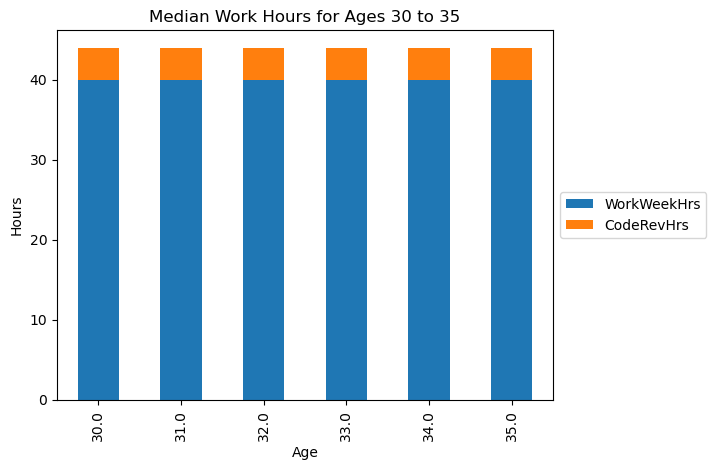

In [77]:
# Create a stacked chart of median WorkWeekHrs and CodeRevHrs for the age group 30 to 35.

df = df_no_outliers[(df_no_outliers['Age'] >= 30) & (df_no_outliers['Age'] <= 35)][['WorkWeekHrs', 'CodeRevHrs', 'Age']]

df = df.groupby('Age').median()

df.plot(kind='bar', stacked=True)
plt.xlabel('Age')
plt.ylabel('Hours')
plt.title('Median Work Hours for Ages 30 to 35')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

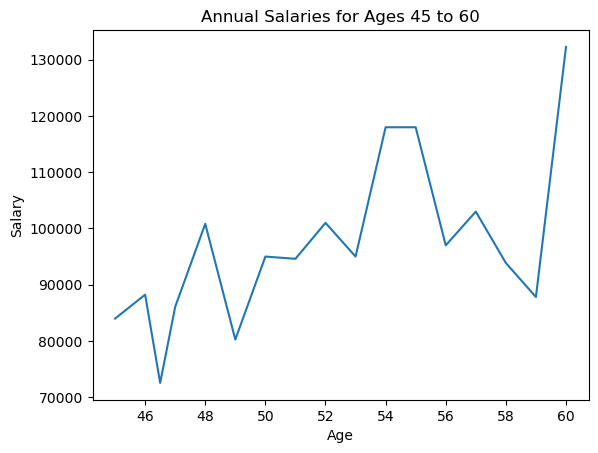

In [79]:
# Create a line plot of the median 'ConvertedComp' for all ages from 45 to 60.

df = df_no_outliers[(df_no_outliers['Age'] >= 45) & (df_no_outliers['Age'] <= 60)][['ConvertedComp', 'Age']]

df = df.groupby('Age').median()

df.plot(kind='line', legend=False)
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Annual Salaries for Ages 45 to 60')
plt.show()

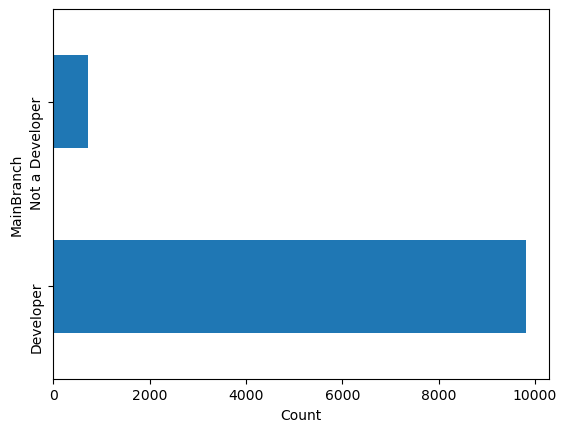

In [81]:
# Create a horizontal bar chart using column 'MainBranch'

main_branch_df = df_no_outliers['MainBranch'].value_counts().to_frame()

main_branch_df.plot(kind='barh', legend=False)
plt.xlabel('Count')
plt.yticks([0,1],['Developer', 'Not a Developer'],rotation='vertical')
#plt.title('Annual Salaries for Ages 45 to 60')
plt.show()